# Kernels and JAX: Derivatives, Gradients and Transforms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/kernels_and_jax.ipynb)

kernellib has no "derivatives" module, and does not need one. Every kernel is an immutable [equinox](https://docs.kidger.site/equinox/) module whose hyperparameters are ordinary JAX arrays, every kernel has a scalar `pairwise(x, y)`, and every estimator's `fit` returns a new module. So JAX's own transformations — `grad`, `jacfwd`, `hessian`, `vmap`, `jit` — compose with everything in the library. This tutorial shows how, from derivatives of a single kernel evaluation up to tuning hyperparameters by gradient descent through a fitted model.

**What you'll learn:**

1. Kernels are PyTrees: jit them, vmap over them, edit them with `eqx.tree_at`.
2. Kernel derivatives $\partial k / \partial x$ and $\partial^2 k / \partial x\, \partial x'$ from `pairwise`, and the derivative Gram blocks for gradient observations.
3. Fitting a function from values *and* slopes.
4. Gradients of a fitted predictor with respect to its inputs.
5. Gradients of a validation loss with respect to hyperparameters, through `fit`, and a small optimisation loop.
6. Input sensitivities of HSIC.
7. Gradients through the matrix-free operators and conjugate gradients.
8. `vmap` over a grid of hyperparameters.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import gaussx as gx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import kernellib as kl


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,equinox,gaussx,kernellib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.17.1

jax      : 0.11.2
equinox  : 0.13.8
gaussx   : 0.2.0
kernellib: 0.0.7

Compiler    : Clang 20.1.4 
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. Kernels are PyTrees

A kernel is a frozen dataclass whose hyperparameters are array leaves. That makes it a valid argument to any JAX transformation, and "changing" a hyperparameter means building a new kernel.

In [4]:
k = kl.RBF(lengthscale=0.5, variance=2.0)
print(k)
print("leaves:", jax.tree_util.tree_leaves(k))

k_long = eqx.tree_at(lambda k: k.lengthscale, k, jnp.asarray(2.0))
print("edited copy:", k_long.lengthscale, " original untouched:", k.lengthscale)

X = jnp.linspace(-1.0, 1.0, 5)[:, None]
gram = jax.jit(lambda kernel, X: kernel(X, X))
print("jit(kernel(X, X)) matches:", bool(jnp.allclose(gram(k, X), k(X, X))))

RBF(lengthscale=weak_f64[], variance=weak_f64[])
leaves: [Array(0.5, dtype=float64, weak_type=True), Array(2., dtype=float64, weak_type=True)]
edited copy: 2.0  original untouched: 0.5


jit(kernel(X, X)) matches: True


Composite kernels are PyTrees too: the sum below has four array leaves, and a gradient with respect to it has the same structure.

In [5]:
k_sum = kl.RBF(lengthscale=0.3) + kl.Matern(nu=1.5, lengthscale=2.0)
grads = jax.grad(lambda kernel: jnp.sum(kernel(X, X)))(k_sum)
for kernel_grad in grads.kernels:
    print(
        type(kernel_grad).__name__, "d/dlengthscale =", float(kernel_grad.lengthscale)
    )

RBF d/dlengthscale = 19.33086963173642
Matern d/dlengthscale = 2.8842528405491623


## 2. Kernel derivatives

`pairwise(x, y)` is the scalar $k(x, y)$ for two points, so its derivatives are one `jax.grad` away. For the RBF kernel $k(x, y) = \sigma^2 \exp(-\|x - y\|^2 / 2\ell^2)$,

$$\frac{\partial k}{\partial x} = -\frac{x - y}{\ell^2}\, k(x, y), \qquad
\frac{\partial^2 k}{\partial x\, \partial y^\top} = \frac{1}{\ell^2}\Big(I - \frac{(x - y)(x - y)^\top}{\ell^2}\Big) k(x, y).$$

In [6]:
k = kl.RBF(lengthscale=0.7, variance=1.5)
x = jnp.array([0.3, -0.2])
y = jnp.array([-0.1, 0.4])

dk_dx = jax.grad(k.pairwise, argnums=0)(x, y)
d2k_dxdy = jax.jacfwd(jax.grad(k.pairwise, argnums=0), argnums=1)(x, y)

r = x - y
kxy = k.pairwise(x, y)
print("dk/dx     autodiff:", dk_dx, " closed form:", -r / 0.7**2 * kxy)
closed = (jnp.eye(2) - jnp.outer(r, r) / 0.7**2) / 0.7**2 * kxy
print("d2k/dxdy  max error vs closed form:", float(jnp.max(jnp.abs(d2k_dxdy - closed))))

dk/dx     autodiff: [-0.72029964  1.08044947]  closed form: [-0.72029964  1.08044947]
d2k/dxdy  max error vs closed form: 2.220446049250313e-16


The same two lines work for any pointwise kernel — Matérn, rational quadratic, sums, products, `ActiveDims`, `Warped` — without anyone writing its derivative by hand.

### Derivative Gram blocks

If $f$ has covariance $k$, then $f$ and its gradient $\nabla f$ are jointly Gaussian with covariances

$$\mathrm{Cov}(f(x), f(y)) = k(x, y), \quad
\mathrm{Cov}(f(x), \nabla f(y)) = \nabla_y k(x, y), \quad
\mathrm{Cov}(\nabla f(x), \nabla f(y)) = \nabla_x \nabla_y^\top k(x, y).$$

`vmap` over pairs of points turns those scalar derivatives into the Gram blocks.

In [7]:
def derivative_gram(kernel, X1, X2):
    """Joint covariance of [f, grad f] at X1 and X2, shape (N1 (1 + D), N2 (1 + D))."""
    k = kernel.pairwise
    dk_dy = jax.grad(k, argnums=1)
    d2k = jax.jacfwd(jax.grad(k, argnums=0), argnums=1)

    def pair(x, y):
        top = jnp.concatenate([k(x, y)[None], dk_dy(x, y)])
        dk_dx = jax.grad(k, argnums=0)(x, y)
        bottom = jnp.concatenate([dk_dx[:, None], d2k(x, y)], axis=1)
        return jnp.concatenate([top[None, :], bottom], axis=0)  # (1 + D, 1 + D)

    blocks = jax.vmap(lambda x: jax.vmap(lambda y: pair(x, y))(X2))(X1)
    n1, n2, p, _ = blocks.shape
    return blocks.transpose(0, 2, 1, 3).reshape(n1 * p, n2 * p)


Xg = jax.random.normal(jax.random.key(0), (6, 2))
G = derivative_gram(kl.Matern(nu=2.5, lengthscale=0.8), Xg, Xg)
print("shape:", G.shape, " symmetric:", bool(jnp.allclose(G, G.T)))
print("smallest eigenvalue:", float(jnp.linalg.eigvalsh(G)[0]))

shape: (18, 18)  symmetric: True


smallest eigenvalue: 0.004473511857785411


The joint Gram matrix is symmetric positive semidefinite, as a covariance must be. Matérn-5/2 sample paths are once differentiable, so these blocks exist; Matérn-1/2 is not differentiable at $x = y$ and has no derivative blocks.

Getting this right needs exact second derivatives *at* coincident points ($x = y$ on the diagonal blocks). kernellib evaluates the kernels that are smooth in $r^2$ — Matérn-3/2 and 5/2, periodic, cosine — through their Taylor expansion in $r^2$ below $r^2 = 10^{-10}$, so autodiff sees the true curvature there instead of the flat spot a `sqrt(clip(r²))` guard would create.

## 3. Fitting a function from values and slopes

With the derivative Gram matrix, gradient observations are just more rows in a kernel ridge regression: solve $(G + \lambda I)\alpha = [f; f']$ and predict $f(x_*) = G(x_*, X)\,\alpha$ using the first row of each test block. Five exact values of a wiggly function are not enough to pin it down; five values *with* their slopes are.

RMSE on [-2, 2], values only:      0.672
RMSE on [-2, 2], values and slopes: 0.019


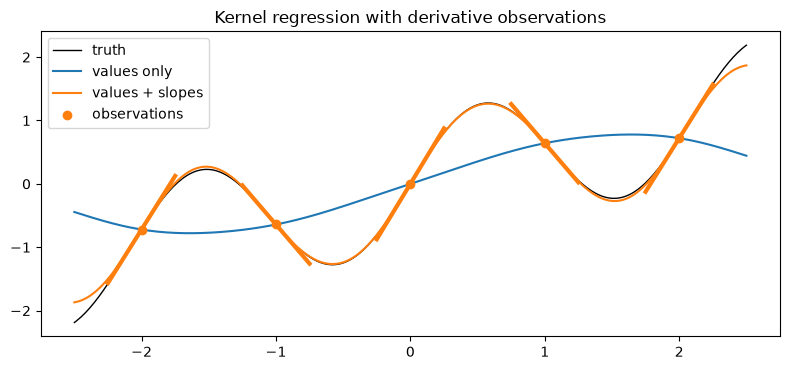

In [8]:
def f_true(x):
    return jnp.sin(3.0 * x) + 0.5 * x


x_obs = jnp.linspace(-2.0, 2.0, 5)[:, None]
values = f_true(x_obs[:, 0])
slopes = jax.vmap(jax.grad(lambda t: f_true(t)))(x_obs[:, 0])
x_star = jnp.linspace(-2.5, 2.5, 300)[:, None]
kern = kl.RBF(lengthscale=0.6, variance=1.0)
ridge = 1e-6

# values only
K = kern(x_obs, x_obs)
mean_values_only = kern(x_star, x_obs) @ jnp.linalg.solve(
    K + ridge * jnp.eye(5), values
)

# values and slopes: rows interleaved as [f(x1), f'(x1), f(x2), f'(x2), ...]
G = derivative_gram(kern, x_obs, x_obs)
targets = jnp.stack([values, slopes], axis=1).reshape(-1)
alpha = jnp.linalg.solve(G + ridge * jnp.eye(G.shape[0]), targets)
G_star = derivative_gram(kern, x_star, x_obs)[::2]  # rows for f(x*), not f'(x*)
mean_with_slopes = G_star @ alpha

truth = f_true(x_star[:, 0])
inside = jnp.abs(x_star[:, 0]) <= 2.0
err_values = jnp.sqrt(jnp.mean((mean_values_only - truth)[inside] ** 2))
err_slopes = jnp.sqrt(jnp.mean((mean_with_slopes - truth)[inside] ** 2))
print(f"RMSE on [-2, 2], values only:      {err_values:.3f}")
print(f"RMSE on [-2, 2], values and slopes: {err_slopes:.3f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(x_star[:, 0], truth, "k", lw=1, label="truth")
ax.plot(x_star[:, 0], mean_values_only, label="values only")
ax.plot(x_star[:, 0], mean_with_slopes, label="values + slopes")
for x0, v, s in zip(x_obs[:, 0], values, slopes, strict=True):
    ax.plot([x0 - 0.25, x0 + 0.25], [v - 0.25 * s, v + 0.25 * s], "C1", lw=3)
ax.scatter(x_obs[:, 0], values, color="C1", zorder=3, label="observations")
ax.legend(loc="upper left")
ax.set_title("Kernel regression with derivative observations")
plt.tight_layout()
plt.show()

The orange ticks are the observed slopes. Nothing here is special-purpose: the derivative Gram matrix came from `jax.grad` of `pairwise`.

## 4. Gradients of a fitted predictor

A fitted `KRR` is a PyTree holding its training inputs and weights, and `predict` is a JAX function of its inputs, so $\partial \hat f / \partial x$ is `jax.grad` of the prediction at one point, vmapped over points.

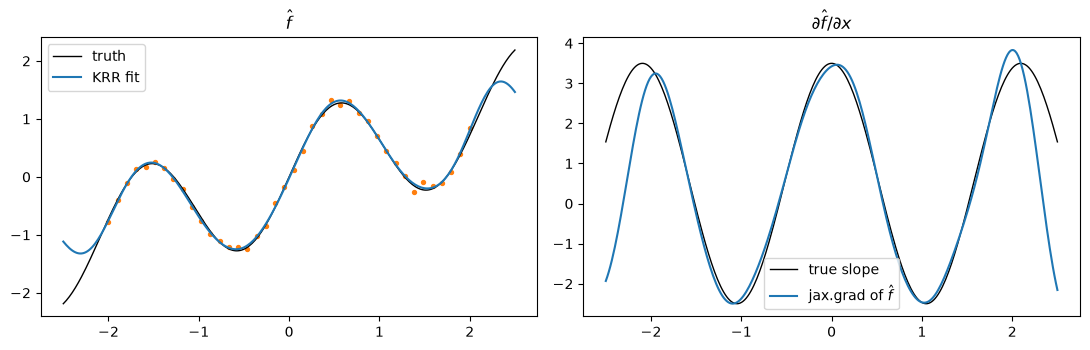

slope RMSE inside the data: 0.165


In [9]:
x_train = jnp.linspace(-2.0, 2.0, 40)[:, None]
y_train = f_true(x_train[:, 0]) + 0.05 * jax.random.normal(jax.random.key(1), (40,))
model = kl.KRR(kl.RBF(lengthscale=0.4), regularization=1e-4).fit(x_train, y_train)


def f_hat(x):
    return model.predict(x[None, :])[0]


grad_f_hat = jax.vmap(jax.grad(f_hat))(x_star)[:, 0]
true_slope = jax.vmap(jax.grad(f_true))(x_star[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(x_star[:, 0], truth, "k", lw=1, label="truth")
axes[0].plot(x_star[:, 0], model.predict(x_star), label="KRR fit")
axes[0].scatter(x_train[:, 0], y_train, s=8, color="C1")
axes[0].set_title(r"$\hat f$")
axes[0].legend()
axes[1].plot(x_star[:, 0], true_slope, "k", lw=1, label="true slope")
axes[1].plot(x_star[:, 0], grad_f_hat, label=r"jax.grad of $\hat f$")
axes[1].set_title(r"$\partial \hat f / \partial x$")
axes[1].legend()
plt.tight_layout()
plt.show()

slope_err = jnp.sqrt(jnp.mean((grad_f_hat - true_slope)[inside] ** 2))
print(f"slope RMSE inside the data: {slope_err:.3f}")

Inside the data the predictor's slope tracks the true slope; outside it the fit reverts to the prior mean of zero and so does its slope. The same pattern gives Jacobians of multi-output models (`jax.jacfwd`) and input sensitivities of `Falkon` or `EigenPro` predictions.

## 5. Hyperparameter gradients through `fit`

Because `fit` is a pure function returning a new module, a validation loss is a differentiable function of the kernel's hyperparameters, *including* everything that happens inside the solve. We optimise the log-lengthscale and log-ridge with a few lines of Adam, starting from a poor guess:

start loss 0.4171 -> final 0.00091
lengthscale 0.288, regularization 3.80e-03


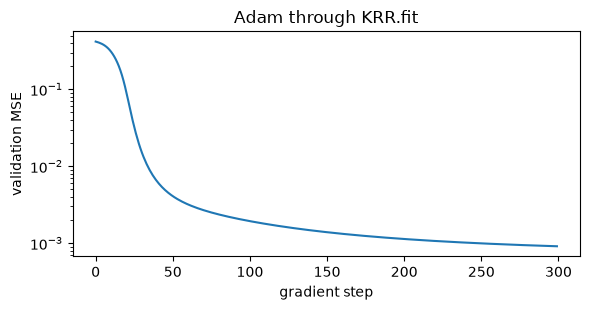

In [10]:
x_val = jnp.linspace(-1.9, 1.9, 25)[:, None]
y_val = f_true(x_val[:, 0])


def validation_loss(log_params):
    log_ell, log_lam = log_params
    kernel = kl.RBF(lengthscale=jnp.exp(log_ell))
    fitted = kl.KRR(kernel, regularization=jnp.exp(log_lam)).fit(x_train, y_train)
    return fitted.loss(x_val, y_val)


loss_and_grad = jax.jit(jax.value_and_grad(validation_loss))


def adam(params, steps, lr=0.05, b1=0.9, b2=0.999):
    m, v, history = jnp.zeros_like(params), jnp.zeros_like(params), []
    for t in range(1, steps + 1):
        loss, g = loss_and_grad(params)
        history.append(float(loss))
        m, v = b1 * m + (1 - b1) * g, b2 * v + (1 - b2) * g * g
        step = (m / (1 - b1**t)) / (jnp.sqrt(v / (1 - b2**t)) + 1e-8)
        params = params - lr * step
    return params, history


params, history = adam(jnp.array([jnp.log(2.0), jnp.log(1e-1)]), 300)
ell_opt, lam_opt = jnp.exp(params)
print(f"start loss {history[0]:.4f} -> final {history[-1]:.5f}")
print(f"lengthscale {ell_opt:.3f}, regularization {lam_opt:.2e}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(history)
ax.set_xlabel("gradient step")
ax.set_ylabel("validation MSE")
ax.set_title("Adam through KRR.fit")
plt.tight_layout()
plt.show()

Each step differentiates through kernel construction, the Cholesky solve, prediction and the loss, all in one jitted function. With `kl.to_operator(..., implicit=True)` and a CG solver the same code runs matrix-free (section 7). Where this run ends up is a *local* optimum; section 8 comes back to that.

## 6. Input sensitivities of HSIC

`kl.hsic` is differentiable in its inputs, so $\partial\, \mathrm{HSIC} / \partial X$ says which input features drive the dependence with $Y$. Below, $Y$ depends on the first feature quadratically (which linear correlation cannot see), on the second not at all, and linearly on the third.

In [11]:
key1, key2 = jax.random.split(jax.random.key(7))
Xs = jax.random.normal(key1, (500, 3))
Ys = Xs[:, :1] ** 2 + 0.5 * Xs[:, 2:3] + 0.1 * jax.random.normal(key2, (500, 1))
kx = kl.RBF(lengthscale=kl.estimate_lengthscale(Xs, ard=True))
ky = kl.RBF(lengthscale=kl.estimate_lengthscale(Ys))

grad_X = jax.grad(lambda X: kl.hsic(kx, ky, X, Ys))(Xs)
sensitivity = jnp.sqrt(jnp.mean(grad_X**2, axis=0))
correlation = jnp.array(
    [jnp.abs(jnp.corrcoef(Xs[:, j], Ys[:, 0])[0, 1]) for j in range(3)]
)
for j in range(3):
    print(
        f"feature {j}: |corr with Y| {correlation[j]:.3f}   "
        f"RMS dHSIC/dx {sensitivity[j]:.2e}"
    )

feature 0: |corr with Y| 0.036   RMS dHSIC/dx 5.62e-05
feature 1: |corr with Y| 0.043   RMS dHSIC/dx 2.98e-05
feature 2: |corr with Y| 0.306   RMS dHSIC/dx 3.99e-05


Correlation ranks the linear feature first and cannot tell the quadratic feature from the unused one. The HSIC gradient ranks the quadratic feature first, the linear one second and the unused one last. The same `jax.grad` with respect to `kx` instead of `X` selects HSIC bandwidths by maximising dependence.

## 7. Gradients through matrix-free operators

`kl.to_operator(kernel, X, implicit=True)` returns an `ImplicitKernelOperator` that never stores the $N \times N$ matrix. Its matvec has a custom JVP rule that carries derivatives with respect to the kernel's hyperparameters, so a gaussx conjugate-gradient solve through it is differentiable — and agrees with differentiating the dense solve.

In [12]:
Xm = jax.random.normal(jax.random.key(4), (300, 2))
ym = jnp.sin(Xm[:, 0]) + 0.1 * jax.random.normal(jax.random.key(5), (300,))
cg = gx.CGSolver(rtol=1e-10, atol=1e-10, max_steps=1000)


def data_fit(ell, implicit):
    kernel = kl.RBF(lengthscale=ell)
    K = kl.to_operator(kernel, Xm, noise=0.1, implicit=implicit)
    alpha = cg.solve(K, ym) if implicit else gx.solve(K, ym)
    return ym @ alpha


for implicit in (False, True):
    value, grad = jax.value_and_grad(data_fit)(0.7, implicit)
    label = "implicit + CG" if implicit else "dense Cholesky"
    print(f"{label:15s} yᵀ(K + σ²I)⁻¹y = {value:.6f}   d/d lengthscale = {grad:.6f}")

dense Cholesky  yᵀ(K + σ²I)⁻¹y = 34.023717   d/d lengthscale = -5.054550


implicit + CG   yᵀ(K + σ²I)⁻¹y = 34.023717   d/d lengthscale = -5.054550


## 8. `vmap` over hyperparameters

Kernels are PyTrees, so a whole grid of kernels is one batched kernel, and `eqx.filter_vmap` fits and scores them all in one vectorised call instead of a Python loop.

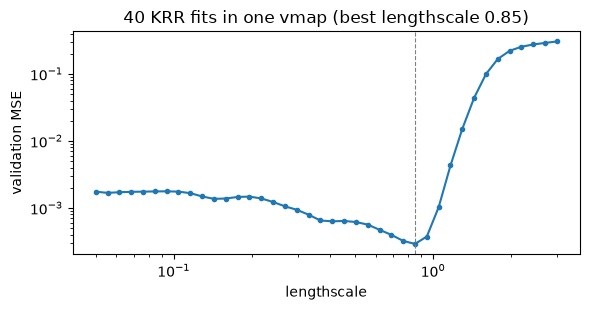

grid optimum: lengthscale 0.851, loss 2.89e-04
Adam from section 5 ended at lengthscale 0.288, loss 9.11e-04


In [13]:
lengthscales = jnp.geomspace(0.05, 3.0, 40)


@eqx.filter_vmap
def score(ell):
    fitted = kl.KRR(kl.RBF(lengthscale=ell), regularization=1e-4).fit(x_train, y_train)
    return fitted.loss(x_val, y_val)


curve = score(lengthscales)
best = lengthscales[jnp.argmin(curve)]

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.loglog(lengthscales, curve, marker=".")
ax.axvline(best, color="grey", ls="--", lw=0.8)
ax.set_xlabel("lengthscale")
ax.set_ylabel("validation MSE")
ax.set_title(f"40 KRR fits in one vmap (best lengthscale {best:.2f})")
plt.tight_layout()
plt.show()

print(f"grid optimum: lengthscale {best:.3f}, loss {jnp.min(curve):.2e}")
print(f"Adam from section 5 ended at lengthscale {ell_opt:.3f}, loss {history[-1]:.2e}")

The validation loss is not convex in the lengthscale. The grid finds a deeper minimum than the one Adam reached from its poor starting point in section 5. The usual recipe combines the two: a cheap vmapped grid to find the right basin, then gradients to refine within it.

In [14]:
refined, refine_history = adam(jnp.array([jnp.log(best), jnp.log(1e-4)]), 100)
print(
    f"refined from the grid optimum: lengthscale {jnp.exp(refined[0]):.3f}, "
    f"regularization {jnp.exp(refined[1]):.1e}, loss {refine_history[-1]:.2e}"
)

refined from the grid optimum: lengthscale 0.917, regularization 4.3e-05, loss 2.62e-04


## Summary

| You want | Write |
|---|---|
| $\partial k(x, y) / \partial x$ | `jax.grad(kernel.pairwise)(x, y)` |
| $\partial^2 k / \partial x\, \partial y^\top$ | `jax.jacfwd(jax.grad(kernel.pairwise, 0), 1)(x, y)` |
| derivative Gram blocks | `vmap` of the above over pairs of points |
| $\partial \hat f / \partial x$ of a fitted model | `jax.vmap(jax.grad(lambda x: model.predict(x[None])[0]))(X)` |
| $\partial\, \text{loss} / \partial\, \theta$ through `fit` | `jax.grad(lambda θ: Estimator(kernel(θ)).fit(X, y).loss(Xv, yv))` |
| input sensitivities of a dependence measure | `jax.grad(lambda X: kl.hsic(kx, ky, X, Y))(X)` |
| gradients of a matrix-free solve | `kl.to_operator(..., implicit=True)` with a gaussx solver |
| a grid of models | `eqx.filter_vmap` over hyperparameters |

Estimators with integer or string configuration (feature counts, solver names) and PRNG keys are best handled with `eqx.filter_grad` / `eqx.filter_jit`, which skip non-array leaves.